# Réaction en Chaîne Nucléaire (2D) — Extension : suivi énergétique + chaleur aux parois

Ce notebook est la suite directe du modèle simple (02). Il suppose que le modèle simple est connu et ne le redéfinit pas. Il ajoute uniquement l'extension énergétique.

## L'extension ajoute :

- Chaque neutron transporte une énergie $E$ (MeV).
- Quand un neutron est absorbé, son énergie est déposée comme chaleur dans le cœur.
- Quand un neutron fuit hors de la grille, son énergie est déposée comme chaleur aux parois.
- Chaque événement de fission crée également des particules chargées :
  - 2 fragments de fission (courte portée, déposent l'essentiel de leur énergie dans le cœur).
  - 3 à 6 électrons bêta (longue portée, certains peuvent atteindre les parois).

## Sorties

- Trajectoires de population neutronique et $k_{eff}$ empirique.
- Bilan énergétique : chaleur déposée dans le cœur vs aux parois, par type de particule.
- Carte de dépôt énergétique dans le cœur.
- Étude paramétrique (fraction U-235, $k_{eff}$, chaleur aux parois).

---

Mdèle simplifié destiné à l'expérimentation ; il ne vise pas une précision de transport de niveau réacteur.


## Imports

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

## Prérequis partagés avec le modèle simple

Les éléments ci-dessous sont identiques à ceux du modèle simple (02).  
Ils sont redéfinis ici pour que ce notebook soit autonome à l'exécution,  
mais aucune logique nouvelle n'y est introduite.


In [9]:
# Paramètres partagés
TAILLE_GRILLE = 50
FRACTION_U    = 0.8

P_FISSION     = 0.10
P_ABS         = 0.30
K_NEUTRONS    = 2.43

N_PAS         = 100
SEED          = 42

DIRECTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]

In [30]:
def watt_sample(rng, a=0.988, b=2.249):
    """spectre de Watt pour neutrons prompts"""
    g = 1.0 + (b * a / 4.0)
    x_max = a * (g + np.sqrt(g**2 - 1.0))
    while True:
        u1, u2 = rng.random(), rng.random()
        x = -a * np.log(u1)
        y = -a * np.log(u2)
        if y >= (x - x_max)**2 / (a * x_max):
            return x


def creer_grille(taille=TAILLE_GRILLE, fraction_uranium=FRACTION_U, rng=None):
    """Grille booléenne : True = U-235, False = vide"""
    rng = np.random.default_rng(rng)
    return rng.random((taille, taille)) < fraction_uranium


def deplacer(i, j, di, dj, taille):
    """Déplace d'une case ; retourne None si la particule sort de la grille"""
    ni, nj = i + di, j + dj
    if not (0 <= ni < taille and 0 <= nj < taille):
        return None
    return (ni, nj)


def classifier_trajectoire(trajectoire, seuil_croissance=20):
    """extinction / quasi-critique / croissance"""
    if trajectoire[-1] == 0:
        return "extinction"
    if np.max(trajectoire) >= seuil_croissance:
        return "croissance"
    return "quasi-critique"


def keff_empirique(trajectoire):
    """k_eff empirique moyen sur la trajectoire"""
    ratios = [trajectoire[t] / trajectoire[t-1]
              for t in range(1, len(trajectoire)) if trajectoire[t-1] > 0]
    return float(np.mean(ratios)) if ratios else 0.0

## Paramètres de l'extension

In [31]:
WATT_A = 0.988
WATT_B = 2.249

# en MeV
FRAG_TKE_MOYENNE = 168.0
FRAG_TKE_SIGMA   = 8.0

# Électrons bêta émis par désintégration des produits de fission
BETA_ENERGIE_TOTALE = 8.0 
BETA_NOMBRE_MIN     = 3
BETA_NOMBRE_MAX     = 6


FRAG_PORTEE_MIN = 1   # fragments très lourds, s'arrêtent rapidement
FRAG_PORTEE_MAX = 2

BETA_PORTEE_MIN = 5   # electrons plus légers, portée plus longue
BETA_PORTEE_MAX = 10

DEPOT_PROGRESSIF = True

## Représentation des particules

| Type | Tuple | Description |
|---|---|---|
| Neutron | `(i, j, di, dj, E)` | E = énergie en MeV |
| Fragment / Bêta | `(i, j, di, dj, E, steps)` | steps = portée restante en cases |

### Compteurs de chaleur

| Compteur | Signification |
|---|---|
| `q_coeur_neutrons` | Absorption de neutrons dans le cœur |
| `q_parois_neutrons` | Fuite de neutrons aux parois |
| `q_coeur_fragments` | Fragments de fission dans le cœur |
| `q_parois_fragments` | Fragments de fission aux parois |
| `q_coeur_betas` | Électrons bêta dans le cœur |
| `q_parois_betas` | Électrons bêta aux parois |


In [32]:
def direction_aleatoire(rng):
    """
    Direction cardinale aléatoire parmi les 4
    """
    return DIRECTIONS[rng.integers(4)]


def direction_opposee(di, dj):
    """
    Direction opposée (conservation de la quantité de mouvement)
    """
    return (-di, -dj)


def creer_neutrons_prompts(rng, n_born, i, j):
    """
    Crée n neutrons prompts à (i, j), énergie tirée selon le spectre de watt
    """
    neutrons = []
    for _ in range(int(n_born)):
        di, dj = direction_aleatoire(rng)
        e = watt_sample(rng, a=WATT_A, b=WATT_B)
        neutrons.append((i, j, di, dj, float(e)))
    return neutrons


def creer_fragments(rng, i, j, tke_total):
    """
    Crée 2 fragments en directions opposées
    """
    di1, dj1 = direction_aleatoire(rng)
    di2, dj2 = direction_opposee(di1, dj1)
    e_chacun = max(float(tke_total) / 2.0, 0.0)
    portee1 = int(rng.integers(FRAG_PORTEE_MIN, FRAG_PORTEE_MAX + 1))
    portee2 = int(rng.integers(FRAG_PORTEE_MIN, FRAG_PORTEE_MAX + 1))
    return [
        (i, j, di1, dj1, e_chacun, portee1),
        (i, j, di2, dj2, e_chacun, portee2),
    ]


def creer_betas(rng, i, j, energie_totale=BETA_ENERGIE_TOTALE):
    """
    Crée 3-6 électrons bêta, énergie répartie aléatoirement (par dirichlet)
    """
    n = max(1, int(rng.poisson(6)))
    poids = rng.dirichlet(np.ones(n))
    betas = []
    for w in poids:
        di, dj = direction_aleatoire(rng)
        e = float(energie_totale * w)
        portee = int(rng.integers(BETA_PORTEE_MIN, BETA_PORTEE_MAX + 1))
        betas.append((i, j, di, dj, e, portee))
    return betas

In [33]:
def deposer_energie(carte_chaleur, i, j, dE):
    """dépose sur la carte thermique en (i, j)"""
    if carte_chaleur is not None:
        carte_chaleur[i, j] += float(dE)


def identifier_paroi(i, j, di, dj, taille):
    """identifie quelle paroi est touchée lors d'une fuite"""
    ni, nj = i + di, j + dj
    if ni < 0:         return "haut",   nj
    if ni >= taille:   return "bas",    nj
    if nj < 0:         return "gauche", ni
    if nj >= taille:   return "droite", ni
    return None, None

## Interaction U-235 étendue

In [14]:
def interaction_uranium_etendue(ni, nj, di, dj, rng,
                                p_fission=P_FISSION, p_abs=P_ABS, k=K_NEUTRONS):
    """
    Interaction d'un neutron (avec énergie) sur une case U-235
    Renvoie l'événement et les nouvelles particules créées
    """
    r = rng.random()

    if r < p_fission:
        n_born = int(rng.poisson(k))
        tke_total = float(max(rng.normal(loc=FRAG_TKE_MOYENNE, scale=FRAG_TKE_SIGMA), 0.0))
        nouveaux_neutrons = creer_neutrons_prompts(rng, n_born, ni, nj)
        fragments = creer_fragments(rng, ni, nj, tke_total=tke_total)
        betas     = creer_betas(rng, ni, nj, energie_totale=BETA_ENERGIE_TOTALE)
        return "fission", nouveaux_neutrons, fragments, betas

    if r < p_fission + p_abs:
        return "absorption", [], [], []

    new_di, new_dj = direction_aleatoire(rng)
    return "diffusion", [(ni, nj, new_di, new_dj)], [], []

## Transport des particules chargées

In [15]:
def avancer_particules_chargees(particules, taille, rng,
                                carte_chaleur_coeur, profil_parois,
                                depot_progressif=True):
    """
    déplace toutes les particules chargées (fragments ou bêtas) d'un pas.
    Gère le dépôt d'énergie dans le cœur et aux parois.
    Particules : une liste de (i, j, di, dj, E, steps)
    """
    restantes = []
    q_parois = 0.0
    q_coeur  = 0.0

    for (i, j, di, dj, E, steps) in particules:
        if steps <= 0 or E <= 0.0:
            continue

        pos = deplacer(i, j, di, dj, taille)

        if pos is None:
            cote, idx = identifier_paroi(i, j, di, dj, taille)
            q_parois += float(E)
            if cote is not None:
                profil_parois[cote][idx] += float(E)
            continue

        ni, nj = pos

        if depot_progressif:
            dE   = float(E) / float(steps)
            dE   = min(dE, float(E))
            deposer_energie(carte_chaleur_coeur, ni, nj, dE)
            q_coeur += dE
            E_new   = float(E) - dE
        else:
            E_new = float(E)

        steps_new = int(steps) - 1

        if steps_new <= 0 or E_new <= 0.0:
            if (not depot_progressif) and E_new > 0.0:
                deposer_energie(carte_chaleur_coeur, ni, nj, E_new)
                q_coeur += E_new
            continue

        restantes.append((ni, nj, di, dj, E_new, steps_new))

    return restantes, float(q_coeur), float(q_parois)

## Pas de temps étendu

In [16]:
def etat_suivant_etendu(neutrons, fragments, betas, grille_uranium, rng,
                        p_fission=P_FISSION, p_abs=P_ABS, k=K_NEUTRONS,
                        depot_progressif=True, suivre_carte=True):
    """
    pas de temps complet du modèle étendu :
    transport des neutrons (avec énergie), déplacement des fragments et bêtas,
    comptabilisation de la chaleur.
    """
    taille = grille_uranium.shape[0]

    carte_chaleur = np.zeros((taille, taille), dtype=float) if suivre_carte else None
    profil_parois = {c: np.zeros(taille, dtype=float) for c in ("haut","bas","gauche","droite")}

    nouveaux_neutrons = []
    fragments_nes     = []
    betas_nes         = []
    q_coeur_neutrons  = 0.0
    q_parois_neutrons = 0.0

    # transport des neutrons
    for (i, j, di, dj, E) in neutrons:
        pos = deplacer(i, j, di, dj, taille)

        if pos is None:
            cote, idx = identifier_paroi(i, j, di, dj, taille)
            q_parois_neutrons += float(E)
            if cote is not None:
                profil_parois[cote][idx] += float(E)
            continue

        ni, nj = pos

        if grille_uranium[ni, nj]:
            evenement, n_nes, f_nes, b_nes = interaction_uranium_etendue(
                ni, nj, di, dj, rng=rng,
                p_fission=p_fission, p_abs=p_abs, k=k
            )
            if evenement == "fission":
                nouveaux_neutrons.extend(n_nes)
                fragments_nes.extend(f_nes)
                betas_nes.extend(b_nes)
            elif evenement == "absorption":
                deposer_energie(carte_chaleur, ni, nj, E)
                q_coeur_neutrons += float(E)
            else:  # diffusion
                di2, dj2 = n_nes[0][2], n_nes[0][3]
                nouveaux_neutrons.append((ni, nj, di2, dj2, float(E)))
        else:
            nouveaux_neutrons.append((ni, nj, di, dj, float(E)))

    # transport des particules chargées
    fragments2, q_coeur_frag, q_parois_frag = avancer_particules_chargees(
        fragments + fragments_nes, taille=taille, rng=rng,
        carte_chaleur_coeur=carte_chaleur, profil_parois=profil_parois,
        depot_progressif=depot_progressif,
    )
    betas2, q_coeur_beta, q_parois_beta = avancer_particules_chargees(
        betas + betas_nes, taille=taille, rng=rng,
        carte_chaleur_coeur=carte_chaleur, profil_parois=profil_parois,
        depot_progressif=depot_progressif,
    )

    compteurs = {
        "q_coeur_neutrons":   float(q_coeur_neutrons),
        "q_parois_neutrons":  float(q_parois_neutrons),
        "q_coeur_fragments":  float(q_coeur_frag),
        "q_parois_fragments": float(q_parois_frag),
        "q_coeur_betas":      float(q_coeur_beta),
        "q_parois_betas":     float(q_parois_beta),
    }
    return nouveaux_neutrons, fragments2, betas2, compteurs, carte_chaleur, profil_parois

## Simulation complète étendue

In [34]:
def simuler_etendu(taille=TAILLE_GRILLE, fraction_uranium=FRACTION_U,
                  p_fission=P_FISSION, p_abs=P_ABS, k=K_NEUTRONS,
                  n_pas=N_PAS, seed=SEED,
                  depot_progressif=DEPOT_PROGRESSIF,
                  suivre_carte=False):
    """
    Simulation COMPLÈTE du modèle étendu
    Renvoie trajectoires, bilan énergétique, carte thermique et profil de parois
    """
    rng = np.random.default_rng(seed)
    grille_uranium = creer_grille(taille, fraction_uranium, rng=rng)

    centre = taille // 2
    di, dj = direction_aleatoire(rng)
    E0 = float(watt_sample(rng, a=WATT_A, b=WATT_B))

    neutrons  = [(centre, centre, di, dj, E0)]
    fragments = []
    betas     = []

    traj_neutrons = [len(neutrons)]
    traj_chargees = [0]
    totaux = Counter()

    carte_chaleur_acc = np.zeros((taille, taille), dtype=float) if suivre_carte else None
    profil_parois_acc = {c: np.zeros(taille, dtype=float) for c in ("haut","bas","gauche","droite")}

    for _ in range(n_pas):
        if not neutrons and not fragments and not betas:
            break

        neutrons, fragments, betas, compteurs, carte_step, profil = etat_suivant_etendu(
            neutrons, fragments, betas,
            grille_uranium=grille_uranium, rng=rng,
            p_fission=p_fission, p_abs=p_abs, k=k,
            depot_progressif=depot_progressif,
            suivre_carte=suivre_carte,
        )
        totaux.update(compteurs)

        if suivre_carte and carte_step is not None:
            carte_chaleur_acc += carte_step

        for cote in profil_parois_acc:
            profil_parois_acc[cote] += profil[cote]

        traj_neutrons.append(len(neutrons))
        traj_chargees.append(len(fragments) + len(betas))

    return {
        "traj_neutrons": np.array(traj_neutrons),
        "traj_chargees": np.array(traj_chargees),
        "grille":        grille_uranium,
        "totaux":        dict(totaux),
        "carte_chaleur": carte_chaleur_acc,
        "profil_parois": profil_parois_acc,
    }

## Simulation unique : visualisation des particules et du bilan énergétique

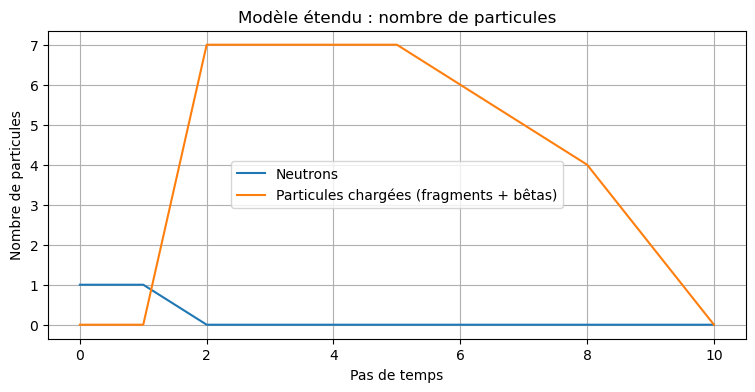

Bilan énergétique (MeV) :
  q_coeur_neutrons               : 0.000 MeV
  q_parois_neutrons              : 0.000 MeV
  q_coeur_fragments              : 150.909 MeV
  q_parois_fragments             : 0.000 MeV
  q_coeur_betas                  : 8.000 MeV
  q_parois_betas                 : 0.000 MeV


In [18]:
res = simuler_etendu(seed=0, suivre_carte=True)

traj_n = res["traj_neutrons"]
traj_c = res["traj_chargees"]

plt.figure(figsize=(9, 4))
plt.plot(traj_n, label="Neutrons")
plt.plot(traj_c, label="Particules chargées (fragments + bêtas)")
plt.title("Modèle étendu : nombre de particules")
plt.xlabel("Pas de temps")
plt.ylabel("Nombre de particules")
plt.grid(True)
plt.legend()
plt.show()

print("Bilan énergétique (MeV) :")
for cle, val in res["totaux"].items():
    print(f"  {cle:<30} : {val:.3f} MeV")

### Tableau du bilan énergétique

In [19]:
def tableau_bilan_energetique(totaux):
    """
    dataframe récapitulatif du bilan énergétique.
    """
    lignes = [
        ("Chaleur cœur  — neutrons",   totaux.get("q_coeur_neutrons",   0.0)),
        ("Chaleur cœur  — fragments",  totaux.get("q_coeur_fragments",  0.0)),
        ("Chaleur cœur  — bêtas",      totaux.get("q_coeur_betas",      0.0)),
        ("Chaleur parois — neutrons",  totaux.get("q_parois_neutrons",  0.0)),
        ("Chaleur parois — fragments", totaux.get("q_parois_fragments", 0.0)),
        ("Chaleur parois — bêtas",     totaux.get("q_parois_betas",     0.0)),
    ]
    df = pd.DataFrame(lignes, columns=["Canal", "Energie (MeV)"])
    df["Energie (MeV)"] = df["Energie (MeV)"].astype(float)
    total = max(df["Energie (MeV)"].sum(), 1e-12)
    df["Fraction (%)"] = (df["Energie (MeV)"] / total * 100).round(2)
    return df

df_energie = tableau_bilan_energetique(res["totaux"])
df_energie

,Canal,Energie (MeV),Fraction (%)
0,Chaleur cœur — neutrons,0.000000,0.00
1,Chaleur cœur — fragments,150.909197,94.97
2,Chaleur cœur — bêtas,8.000000,5.03
3,Chaleur parois — neutrons,0.000000,0.00
4,Chaleur parois — fragments,0.000000,0.00
5,Chaleur parois — bêtas,0.000000,0.00


### Répartition cœur / parois

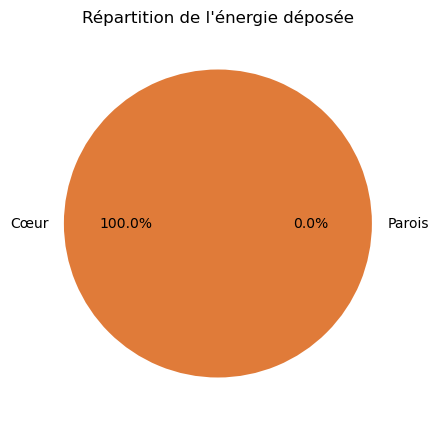

In [20]:
chaleur_coeur  = df_energie[df_energie["Canal"].str.contains("cœur")]["Energie (MeV)"].sum()
chaleur_parois = df_energie[df_energie["Canal"].str.contains("parois")]["Energie (MeV)"].sum()

plt.figure(figsize=(5, 5))
plt.pie(
    [chaleur_coeur, chaleur_parois],
    labels=["Cœur", "Parois"],
    autopct="%1.1f%%",
    colors=["#e07b39", "#3a7ebf"]
)
plt.title("Répartition de l'énergie déposée")
plt.show()

### Profil de chaleur le long des 4 parois

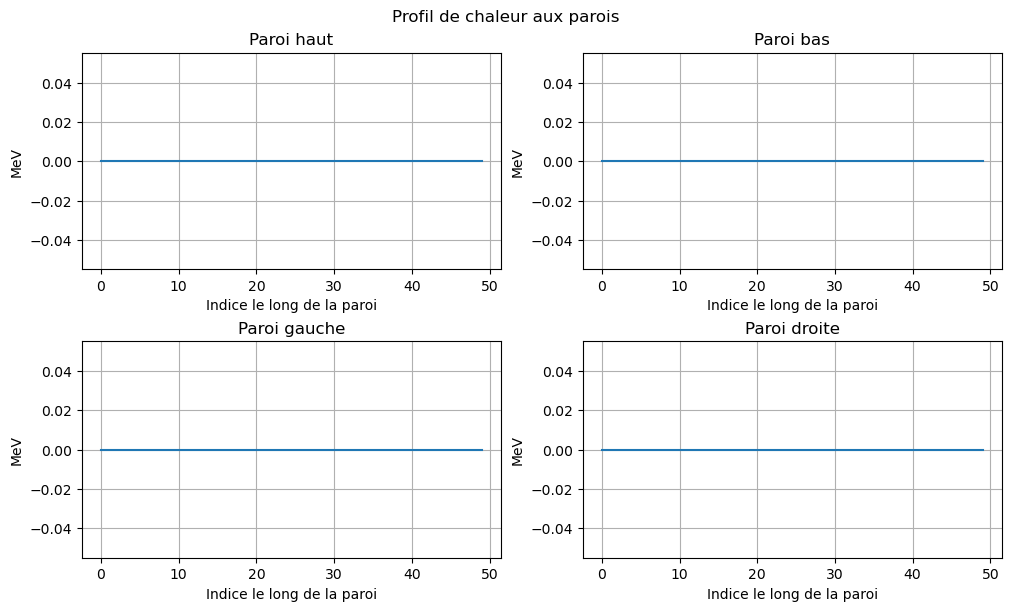

In [21]:
pp = res["profil_parois"]

fig, axs = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
for ax, cote in zip(axs.flatten(), ["haut", "bas", "gauche", "droite"]):
    ax.plot(pp[cote])
    ax.set_title(f"Paroi {cote}")
    ax.set_xlabel("Indice le long de la paroi")
    ax.set_ylabel("MeV")
    ax.grid(True)
plt.suptitle("Profil de chaleur aux parois")
plt.show()

### Carte thermique du cœur

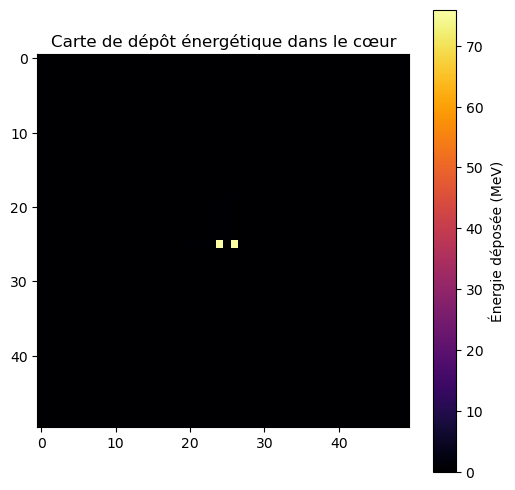

In [22]:
carte = res["carte_chaleur"]

plt.figure(figsize=(6, 6))
plt.imshow(carte, cmap="inferno")
plt.colorbar(label="Énergie déposée (MeV)")
plt.title("Carte de dépôt énergétique dans le cœur")
plt.show()

## Simulations multiples

In [23]:
def simuler_plusieurs(n_runs=30, **kwargs):
    """
    Lance n_runs simulations étendues et renvoie un dataframe de résultats.
    """
    lignes = []
    for seed in range(n_runs):
        r = simuler_etendu(seed=seed, suivre_carte=False, **kwargs)
        traj   = r["traj_neutrons"]
        totaux = r["totaux"]

        chaleur_parois = float(
            totaux.get("q_parois_neutrons",  0.0) +
            totaux.get("q_parois_fragments", 0.0) +
            totaux.get("q_parois_betas",     0.0)
        )
        chaleur_coeur = float(
            totaux.get("q_coeur_neutrons",   0.0) +
            totaux.get("q_coeur_fragments",  0.0) +
            totaux.get("q_coeur_betas",      0.0)
        )
        lignes.append({
            "seed":              seed,
            "classe":            classifier_trajectoire(traj),
            "k_eff":             keff_empirique(traj),
            "max_neutrons":      int(traj.max()),
            "neutrons_finaux":   int(traj[-1]),
            "chaleur_parois_MeV": chaleur_parois,
            "chaleur_coeur_MeV":  chaleur_coeur,
        })
    return pd.DataFrame(lignes)

df_ext = simuler_plusieurs(n_runs=30)
df_ext.head()

,seed,classe,k_eff,max_neutrons,neutrons_finaux,chaleur_parois_MeV,chaleur_coeur_MeV
0,0,extinction,0.500000,1,0,0.0,158.909197
1,1,extinction,0.833333,1,0,0.0,0.589934
2,2,extinction,0.950000,2,0,0.0,180.217681
3,3,extinction,0.937500,2,0,0.0,346.313224
4,4,extinction,0.875000,1,0,0.0,0.102220


In [24]:
print("Bilan Global (30 runs, modèle étendu)")
print(f"Extinctions           : {(df_ext['classe'] == 'extinction').sum()}")
print(f"Quasi-critiques       : {(df_ext['classe'] == 'quasi-critique').sum()}")
print(f"Croissances           : {(df_ext['classe'] == 'croissance').sum()}")
print(f"k_eff moyen           : {df_ext['k_eff'].mean():.3f}")
print(f"k_eff écart-type      : {df_ext['k_eff'].std():.3f}")
print(f"Chaleur parois totale : {df_ext['chaleur_parois_MeV'].sum():.2f} MeV")
print(f"Chaleur cœur totale   : {df_ext['chaleur_coeur_MeV'].sum():.2f} MeV")

Bilan Global (30 runs, modèle étendu)
Extinctions           : 30
Quasi-critiques       : 0
Croissances           : 0
k_eff moyen           : 0.645
k_eff écart-type      : 0.383
Chaleur parois totale : 0.00 MeV
Chaleur cœur totale   : 5527.26 MeV


In [25]:
ETA_COLLECTIBLE = 0.94
ETA_THERMIQUE = 0.33

chaleur_coeur_totale = df_ext['chaleur_coeur_MeV'].mean()

energie_electrique_nette = chaleur_coeur_totale * ETA_COLLECTIBLE * ETA_THERMIQUE
print(energie_electrique_nette)

57.15187880751908
